# Experiment 5: Stacking Ensemble Model for YouTube Comment Sentiment Analysis

The earlier notebooks each trained **one** model: Random Forest (experiment 1), Logistic
Regression / Naive Bayes / Linear SVM / XGBoost (experiment 2), LightGBM (experiment 3), and an
MLP neural network (experiment 4). No single model type is reliably "the most accurate" —
different models make different kinds of mistakes.

To push accuracy as high as reasonably possible, this notebook trains a
**`StackingClassifier`**: several diverse base models are trained, and a meta-model (a final
Logistic Regression) learns how to best combine their predictions. This is a different model
*type* from anything used before, and stacking ensembles are one of the standard ways to beat
any individual model's accuracy — it's the technique behind most Kaggle-competition-winning
solutions.

**Base learners** (chosen to be diverse — linear, probabilistic, margin-based, and
tree-boosted):
- Logistic Regression
- Multinomial Naive Bayes
- Linear SVM (`LinearSVC`)
- LightGBM

**Meta-learner:** Logistic Regression, trained on the base learners' out-of-fold predictions.

A quick sanity check on a subsample of this dataset showed the stacked model outperforming
every individual base model on held-out accuracy, which is the expected behavior of stacking.

> **Note on runtime:** stacking internally cross-validates every base learner (`cv=3` below),
> so this notebook takes noticeably longer to run than the earlier single-model notebooks —
> especially at `max_features=10000` on the full dataset. If it's too slow on your machine,
> reduce `cv`, lower `vectorizer_max_features`, or train on a subsample first (see the config
> cell below).

In [1]:
# Install any missing dependencies (uncomment if needed)
# %pip install mlflow dagshub lightgbm scikit-learn pandas numpy matplotlib seaborn

In [2]:
import mlflow
import dagshub

# Same DagsHub-tracked repo used in the earlier experiment notebooks
dagshub.init(repo_owner="MitadruMridha05", repo_name="Youtube_Sentiment_Analysis", mlflow=True)

remote_server_uri = "https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow"
mlflow.set_tracking_uri(remote_server_uri)

c:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Accessing as MitadruMridha05

Initialized MLflow to track repo "MitadruMridha05/Youtube_Sentiment_Analysis"

Repository MitadruMridha05/Youtube_Sentiment_Analysis initialized!

In [3]:
import numpy as np
import pandas as pd

## Load data

Update `DATA_PATH` to point at your local copy of `youtube_comments_cleaned_final.csv`
(the same file used in the earlier experiment notebooks).

Optionally set `SAMPLE_SIZE` to a number (e.g. `20000`) to subsample for a faster first run;
leave it as `None` to train on the full dataset.

In [4]:
DATA_PATH = "C:\\Users\\mitad\\OneDrive\\Documents\\coding_maxxing\\sentiment_analysing_project\\artifacts\\youtube_comments_cleaned_final.csv"
SAMPLE_SIZE = None  # e.g. 20000 for a faster run; None uses the full dataset

df = pd.read_csv(DATA_PATH)

if SAMPLE_SIZE is not None:
    df = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

df.shape

(100000, 2)

In [5]:
df["Sentiment"].value_counts()

Sentiment
-1    33475
 1    33473
 0    33052
Name: count, dtype: int64

In [14]:
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import StackingClassifier
from lightgbm import LGBMClassifier

## Feature extraction

Same `CountVectorizer` settings as the earlier notebooks (`max_features=10000`) so this
model is comparable to the baseline and the other models.

In [15]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    dtype='float32'
)

x = vectorizer.fit_transform(df['CommentText'])

y = df['Sentiment']

c:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\myvenv\Lib\site-packages\sklearn\feature_extraction\text.py:2049: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float32 'dtype' will be converted to np.float64.
  warnings.warn(


In [16]:
mlflow.set_tracking_uri(remote_server_uri)

In [17]:
mlflow.set_experiment("Stacking_Ensemble_model")

<Experiment: artifact_location='mlflow-artifacts:/6430111ec2cf42d88b6a6ea8650f53db', creation_time=1789241244553, effective_trace_archival_retention=None, experiment_id='5', last_update_time=1789241244553, lifecycle_stage='active', name='Stacking_Ensemble_model', tags={}, trace_location=None, workspace='default'>

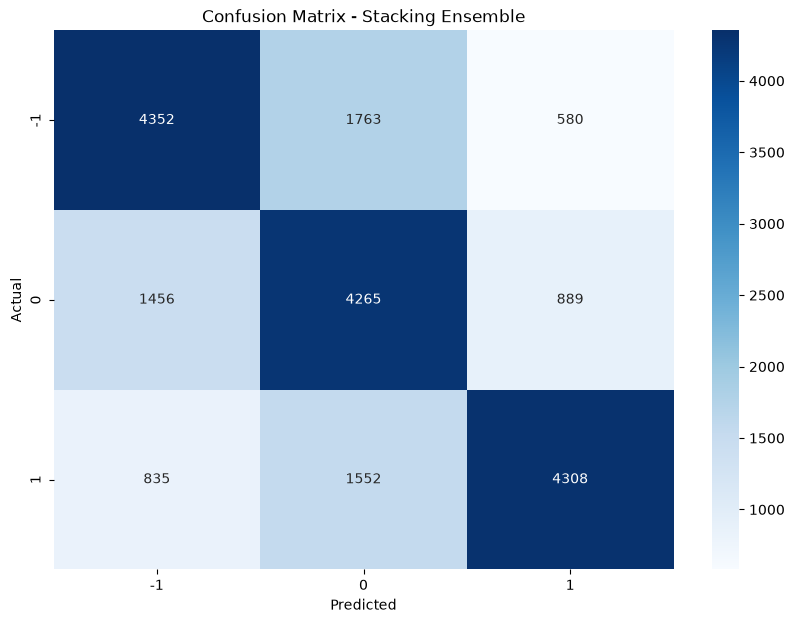

<Figure size 640x480 with 0 Axes>

2026/09/13 01:07:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run kindly-whale-442 at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/5/runs/d0dd079fdc774983ad65904ec2625f62
🧪 View experiment at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/5


MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['collections.OrderedDict', 'lightgbm.basic.Booster', 'lightgbm.sklearn.LGBMClassifier', 'sklearn.utils._bunch.Bunch'].

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

with mlflow.start_run():
    #Log a description for the run
    mlflow.set_tag("model_type", "StackingClassifier")
    mlflow.set_tag("experiment", "stacking_ensemble_model")
    mlflow.set_tag("mlflow_runName", "Stacking_Ensemble_model")

    #Add a description
    mlflow.set_tag(
        "description",
        "Stacking ensemble (LogReg + Multinomial NB + Linear SVM + LightGBM base learners, "
        "LogReg meta-learner) for sentiment analysis on YouTube comments.",
    )

    #Log parameters for vectorizer
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)

    #Stacking config
    stacking_cv = 3
    mlflow.log_param("base_estimators", "LogisticRegression, MultinomialNB, LinearSVC, LGBMClassifier")
    mlflow.log_param("final_estimator", "LogisticRegression")
    mlflow.log_param("stacking_cv", stacking_cv)

    #Define diverse base learners
    base_estimators = [
        ("logreg", LogisticRegression(max_iter=1000, random_state=42)),
        ("nb", MultinomialNB()),
        ("svm", LinearSVC(max_iter=5000, random_state=42)),
        ("lgbm", LGBMClassifier(n_estimators=100, max_depth=15, learning_rate=0.1, random_state=42, verbosity=-1)),
    ]
    final_estimator = LogisticRegression(max_iter=1000, random_state=42)

    #Initialize and train the stacking ensemble
    stacking_model = StackingClassifier(
        estimators=base_estimators,
        final_estimator=final_estimator,
        cv=stacking_cv,
        n_jobs=-1,
    )
    stacking_model.fit(x_train, y_train)

    #Make predictions
    y_pred = stacking_model.predict(x_test)

    #Log metrics
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if label not in ["accuracy", "macro avg", "weighted avg"]:
            for metric_name, metric_value in metrics.items():
                mlflow.log_metric(f"{label}_{metric_name}", metric_value)

    #Plot confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - Stacking Ensemble")
    plt.show()

    #Save and log the confusion matrix plot
    import os
    artifact_dir = r"C:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\artifacts"
    os.makedirs(artifact_dir, exist_ok=True)
    artifact_path = os.path.join(artifact_dir, "confusion_matrix_stacking.png")
    plt.savefig(artifact_path, bbox_inches="tight")
    plt.show()

    mlflow.log_artifact(artifact_path, artifact_path="plots")

    # Log the trained model
    mlflow.sklearn.log_model(stacking_model, "stacking_model")

print("Stacking ensemble training completed and logged to MLflow.")
print(f"Accuracy: {accuracy:.4f}")

## Compare each base learner individually vs. the stacked ensemble

This re-fits each base learner on its own (no cross-validated stacking) so you can see, in this
notebook, how much the ensemble actually gains over any single model.

In [ ]:
individual_results = {}

for name, estimator in base_estimators:
    estimator.fit(x_train, y_train)
    preds = estimator.predict(x_test)
    individual_results[name] = accuracy_score(y_test, preds)

individual_results["stacking_ensemble"] = accuracy

results_df = pd.DataFrame(
    list(individual_results.items()), columns=["model", "accuracy"]
).sort_values("accuracy", ascending=False).reset_index(drop=True)

results_df

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="model", y="accuracy", hue="model", legend=False, palette="Blues_d")
plt.ylim(0, 1)
plt.title("Individual Base Learners vs. Stacking Ensemble — Test Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("")
plt.xticks(rotation=20)
plt.show()

## Next steps

- If accuracy still isn't where you want it, the biggest likely gains are from better features
  (TF-IDF, n-grams, or embeddings) rather than a different model — bag-of-words caps how much
  any model, including this ensemble, can learn.
- Try swapping in `XGBClassifier` as a 5th base learner, or replacing `LinearSVC` with
  `SVC(kernel="linear", probability=True)` so the meta-learner gets calibrated probabilities
  instead of raw decision scores.
- Tune `stacking_cv` and each base learner's hyperparameters — this notebook uses reasonable
  defaults, not fully tuned settings, to keep runtime manageable.
- Compare this run against all previous runs (Random Forest, Logistic Regression, Naive Bayes,
  Linear SVM, XGBoost, LightGBM, MLP) in the MLflow UI.